In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from statsmodels.tsa.stattools import adfuller

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef, cohen_kappa_score,
    log_loss, brier_score_loss, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

2026-07-12 19:19:53.025527: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-12 19:19:53.737225: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2026-07-12 19:19:53.737341: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory
2026-07-12 19:19:53.737349: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Cannot dlopen some TensorRT libraries. If you would like to use Nv

In [2]:
# Load the dataset
csv_path = Path("/home/dev-algo/Documents/WLV-MSc-AI/05_Applying_Artificial_Intelligence/CME_ES1_1D.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Dataset not found: {csv_path.resolve()}")

raw_df = pd.read_csv(csv_path, sep=";")
print("Raw shape:", raw_df.shape)
print("Raw columns:", list(raw_df.columns))

df = raw_df.copy()
if df.shape[1] == 1 and df.columns[0].startswith("time,"):
    df = df.iloc[:, 0].str.split(",", expand=True)
    df.columns = ["time", "open", "high", "low", "close", "MA 9", "MA 21", "EMA 55", "EMA 125", "EMA 200", "EMA 350"]

df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")

invalid_ts = df["time"].isna().sum()
dup_count_before = df.duplicated().sum()

df = df.dropna(subset=["time"]).drop_duplicates().sort_values("time").set_index("time")

print("\nInvalid timestamps removed:", invalid_ts)
print("Duplicate rows removed:", dup_count_before)
print("Final shape:", df.shape)
print("\nMissing values per column:\n", df.isna().sum())
print("\nData types:\n", df.dtypes)

Raw shape: (6944, 1)
Raw columns: ['time,open,high,low,close,MA 9,MA 21,EMA 55,EMA 125,EMA 200,EMA 350']

Invalid timestamps removed: 0
Duplicate rows removed: 0
Final shape: (6944, 10)

Missing values per column:
 open       0
high       0
low        0
close      0
MA 9       0
MA 21      0
EMA 55     0
EMA 125    0
EMA 200    0
EMA 350    0
dtype: int64

Data types:
 open       object
high       object
low        object
close      object
MA 9       object
MA 21      object
EMA 55     object
EMA 125    object
EMA 200    object
EMA 350    object
dtype: object


In [3]:
# Core features
df["lag_close_1"] = df["close"].shift(1)
df["lag_close_3"] = df["close"].shift(3)
df["lag_close_7"] = df["close"].shift(7)

# Return and volatility features
# Ensure numeric columns are numeric before feature engineering
for col in ["open", "high", "low", "close"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["ret_1d"] = df["close"].pct_change(1)
df["ret_7d"] = df["close"].pct_change(7)
df["volatility_7d"] = df["ret_1d"].rolling(7).std()

# Ratio features
df["high_low_ratio"] = df["high"] / df["low"]
# Ensure lag columns are numeric before using them
for lag in ["lag_close_1", "lag_close_3", "lag_close_7"]:
    if lag in df.columns:
        df[lag] = pd.to_numeric(df[lag], errors="coerce")

# Compute range ratio, avoiding division by zero
df["range_ratio"] = (df["high"] - df["low"]) / df["lag_close_1"].replace({0: np.nan})
df["open_ratio"] = df["open"] / df["lag_close_1"]

# Target: predict next-day direction
df["price_direction"] = (df["close"].shift(-1) > df["close"]).astype(int)

# Rolling trend feature for plotting/reporting
df["rolling_mean_30"] = df["close"].rolling(window=30).mean()

# Drop rows with NaN introduced by shifts/rolling
df_model = df.dropna().copy()

baseline_features = ["open", "high", "low", "lag_close_1"]
fe_features = baseline_features + [
    "lag_close_3", "lag_close_7",
    "ret_1d", "ret_7d", "volatility_7d",
    "high_low_ratio", "range_ratio", "open_ratio"
]

X_bl = df_model[baseline_features]
X_fe = df_model[fe_features]
y = df_model["price_direction"]

selected_df = df_model[baseline_features + ["close"]]

print("Model dataset shape:", df_model.shape)
print("\nClass balance:\n", y.value_counts(normalize=True).rename("proportion"))
print("\nSelected features preview:")
selected_df.head()

Model dataset shape: (6915, 21)

Class balance:
 price_direction
1    0.534779
0    0.465221
Name: proportion, dtype: float64

Selected features preview:


,open,high,low,lag_close_1,close
time,,,,,
1999-03-11 00:00:00+00:00,1305.2,1305.20,1304.20,1289.00,1304.50
1999-03-12 00:00:00+00:00,1305.2,1309.00,1289.20,1304.50,1291.20
1999-03-15 00:00:00+00:00,1319.0,1319.00,1318.75,1291.20,1318.75
1999-03-16 00:00:00+00:00,1318.5,1319.00,1318.25,1318.75,1318.50
1999-03-17 00:00:00+00:00,1310.5,1311.75,1310.50,1318.50,1311.50


In [4]:
desc = X_fe.describe().T
desc["skew"] = X_fe.skew()
desc["kurtosis"] = X_fe.kurtosis()
print("Detailed descriptive statistics:\n")
display(desc[["mean", "std", "min", "25%", "50%", "75%", "max", "skew", "kurtosis"]])

# IQR outlier share
outlier_share = {}
for col in X_fe.columns:
    q1, q3 = X_fe[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_share[col] = ((X_fe[col] < lower) | (X_fe[col] > upper)).mean() * 100

outlier_df = pd.Series(outlier_share, name="outlier_%").sort_values(ascending=False)
print("\nOutlier share by feature (%):")
display(outlier_df.round(2).to_frame())

# ADF stationarity test on close
adf_stat, adf_pvalue, *_ = adfuller(df_model["close"])
print(f"ADF statistic: {adf_stat:.4f}")
print(f"ADF p-value: {adf_pvalue:.6f}")
if adf_pvalue > 0.05:
    print("Interpretation: likely non-stationary (trend/structural changes present).")
else:
    print("Interpretation: likely stationary series.")

Detailed descriptive statistics:



,mean,std,min,25%,50%,75%,max,skew,kurtosis
open,2331.575582,1578.742563,674.750000,1223.500000,1516.250000,2917.125000,7628.000000,1.415276,1.133816
high,2348.163803,1588.632094,694.750000,1233.750000,1527.000000,2936.250000,7648.750000,1.414139,1.125551
low,2314.124751,1568.532615,665.750000,1216.250000,1506.500000,2896.750000,7591.750000,1.416524,1.143703
lag_close_1,2331.579067,1578.580949,676.000000,1223.625000,1517.250000,2920.625000,7626.500000,1.415183,1.134162
lag_close_3,2329.750362,1576.131495,676.000000,1223.625000,1516.500000,2919.375000,7626.500000,1.414353,1.130277
lag_close_7,2326.104881,1571.333496,676.000000,1223.625000,1516.250000,2917.750000,7626.500000,1.412902,1.123647
ret_1d,0.000330,0.012086,-0.103765,-0.004677,0.000630,0.005890,0.141134,0.047408,11.885834
ret_7d,0.002223,0.028400,-0.237484,-0.011531,0.004426,0.017847,0.170858,-0.687302,5.119376
volatility_7d,0.009911,0.007278,0.000938,0.005434,0.008156,0.012246,0.078879,3.383998,19.591387
high_low_ratio,1.015733,0.012026,1.000190,1.008380,1.012717,1.019210,1.139619,3.420856,20.106718



Outlier share by feature (%):


,outlier_%
open_ratio,13.56
high,7.26
open,7.17
lag_close_1,7.17
low,7.14
lag_close_3,7.14
lag_close_7,7.10
ret_1d,6.83
high_low_ratio,5.15
range_ratio,4.96


ADF statistic: 3.4208
ADF p-value: 1.000000
Interpretation: likely non-stationary (trend/structural changes present).


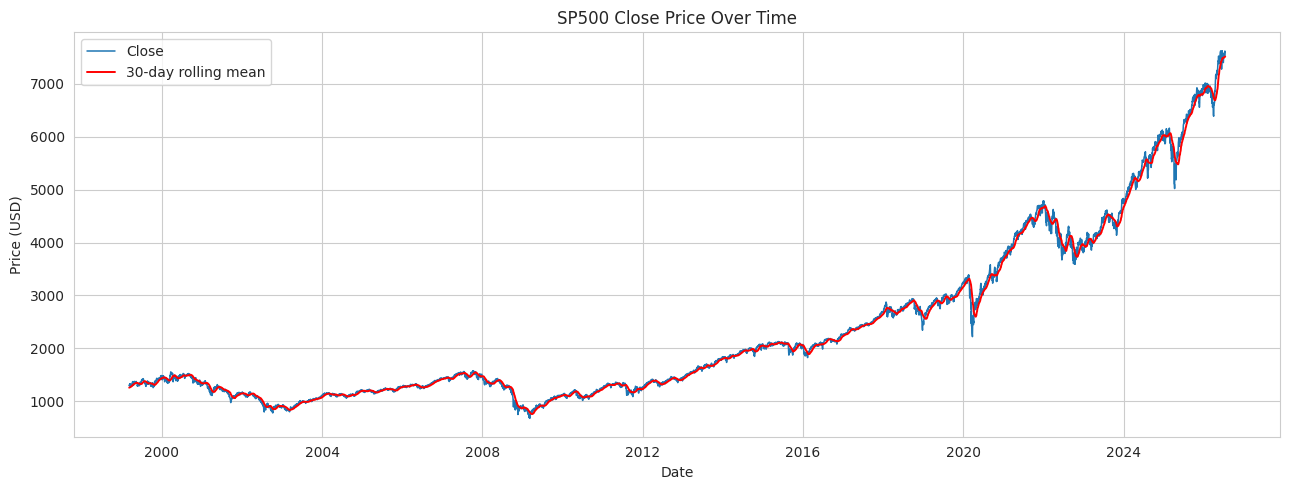

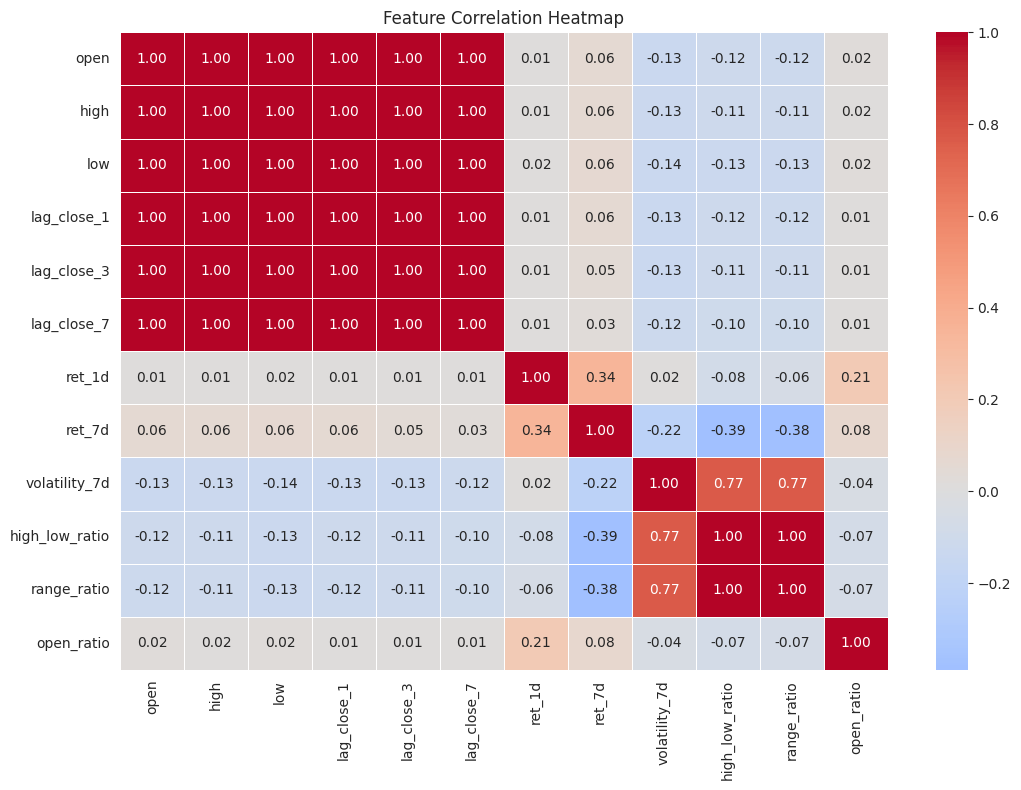

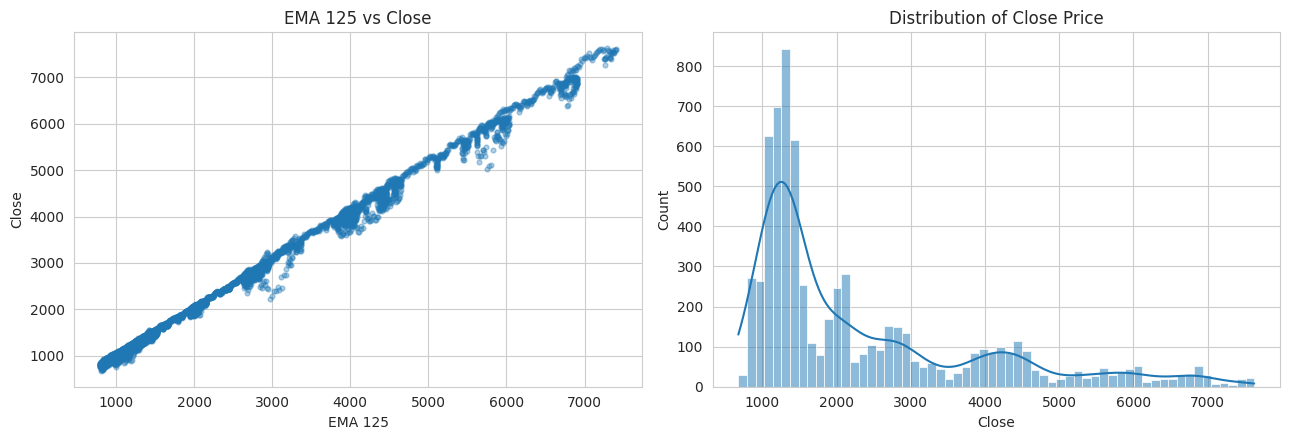

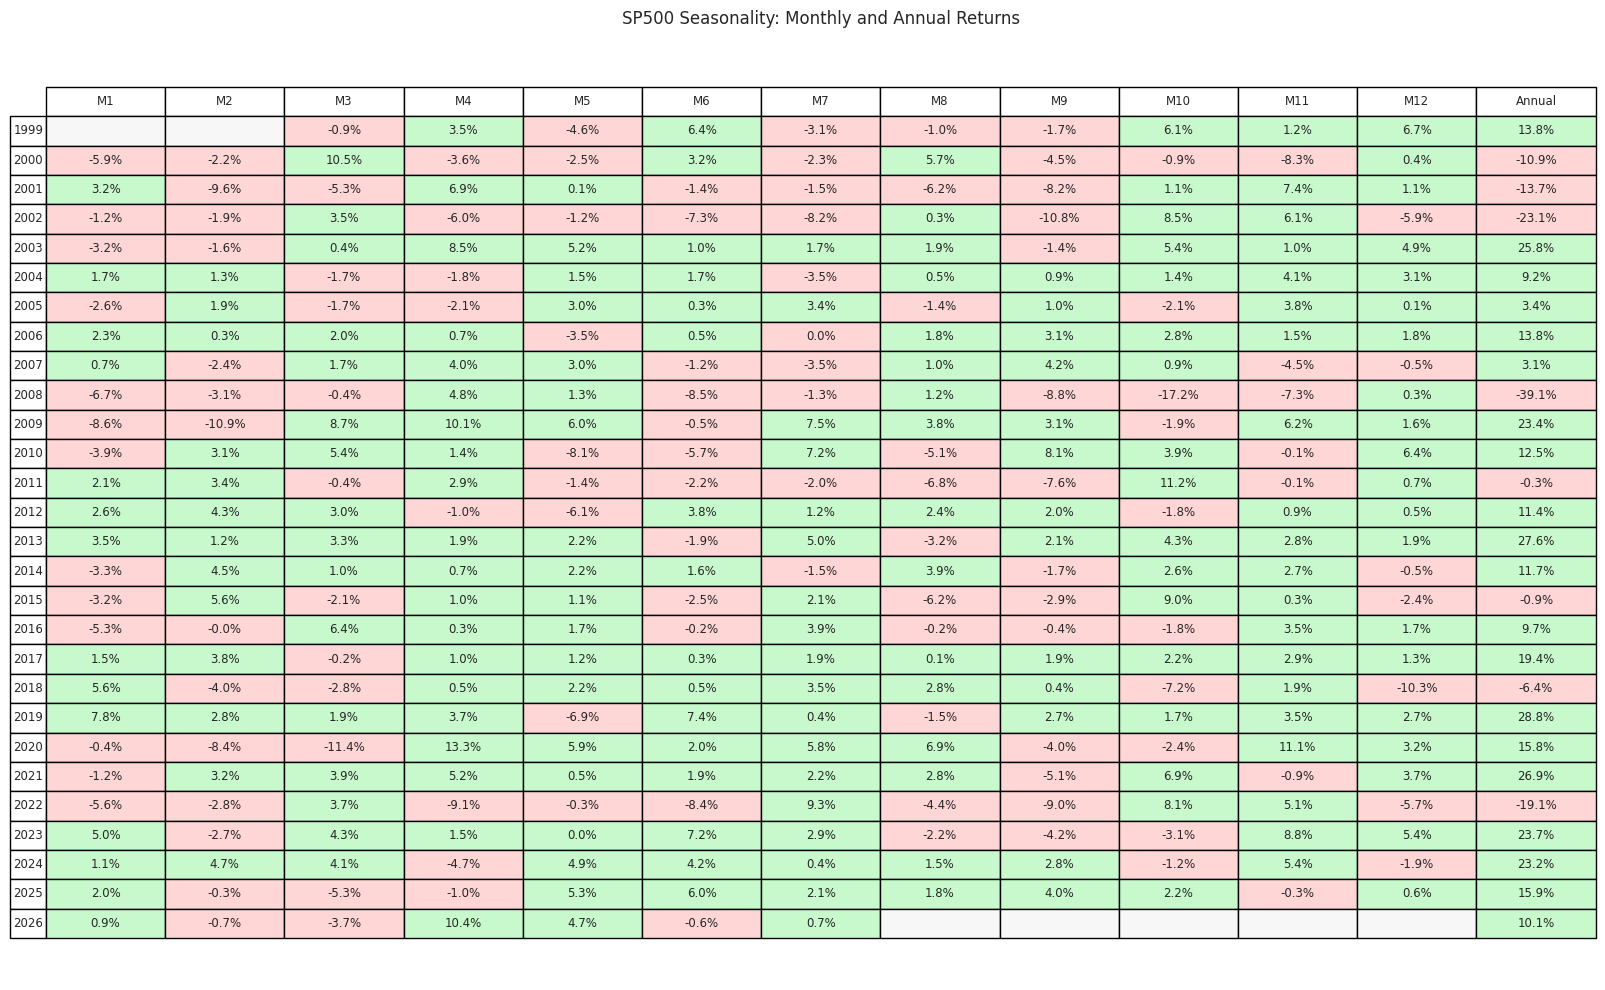

In [5]:
# Trend plot
plt.figure(figsize=(13, 5))
plt.plot(df_model.index, df_model["close"], label="Close", linewidth=1.1)
plt.plot(df_model.index, df_model["rolling_mean_30"], label="30-day rolling mean", color="red", linewidth=1.4)
plt.title("SP500 Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

# Correlation heatmap with annotations
plt.figure(figsize=(11, 8))
sns.heatmap(X_fe.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Scatter and histogram
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(pd.to_numeric(df_model["EMA 125"], errors="coerce"), df_model["close"], alpha=0.35, s=12)
axes[0].set_title("EMA 125 vs Close")
axes[0].set_xlabel("EMA 125")
axes[0].set_ylabel("Close")

sns.histplot(df_model["close"], bins=60, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Close Price")
axes[1].set_xlabel("Close")

plt.tight_layout()
plt.show()

# Seasonality table with percentage returns
tmp = df_model.copy()
tmp["year"] = tmp.index.year
tmp["month"] = tmp.index.month

monthly = tmp.groupby(["year", "month"]).agg(
    open_start=("open", "first"),
    close_end=("close", "last"),
    vol_month=("close", "std"),
)
monthly["ret_month_pct"] = ((monthly["close_end"] - monthly["open_start"]) / monthly["open_start"]) * 100

annual = tmp.groupby("year").agg(
    open_start=("open", "first"),
    close_end=("close", "last"),
    vol_year=("close", "std"),
)
annual["ret_year_pct"] = ((annual["close_end"] - annual["open_start"]) / annual["open_start"]) * 100

seasonality_rows = sorted(tmp["year"].unique())
seasonality_cols = list(range(1, 13)) + [13]
col_labels = [f"M{m}" for m in range(1, 13)] + ["Annual"]

cell_text = []
cell_colors = []

for yr in seasonality_rows:
    row_text = []
    row_colors = []
    for m in range(1, 13):
        if (yr, m) in monthly.index:
            r = monthly.loc[(yr, m), "ret_month_pct"]
            row_text.append(f"{r:.1f}%")
            row_colors.append("#c7f9cc" if r > 0 else "#ffd6d6")
        else:
            row_text.append("")
            row_colors.append("#f7f7f7")

    r_a = annual.loc[yr, "ret_year_pct"]
    row_text.append(f"{r_a:.1f}%")
    row_colors.append("#c7f9cc" if r_a > 0 else "#ffd6d6")

    cell_text.append(row_text)
    cell_colors.append(row_colors)

fig, ax = plt.subplots(figsize=(16, 10))
ax.axis("off")
tbl = ax.table(
    cellText=cell_text,
    rowLabels=seasonality_rows,
    colLabels=col_labels,
    cellColours=cell_colors,
    cellLoc="center",
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1.08, 1.45)
plt.title("SP500 Seasonality: Monthly and Annual Returns", pad=15)
plt.tight_layout()
plt.show()